# CNN + TRANSFER LEARNING (Worksheet 6)


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ========================
# Simple CNN Model (MNIST)
# ========================

model = keras.Sequential([
    # Rescaling layer: normalizes pixel values from [0,255] to [0,1] inside the model
    layers.Rescaling(1./255, input_shape=(28, 28, 1)),

    # First convolutional block
    # 32 filters of size 3x3, learn 32 different low-level features (edges, curves)
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),   # Reduce spatial size by 2x (28x28 → 13x13)

    # Second convolutional block
    # 64 filters: learn more complex combinations of low-level features
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),   # Reduce further (13x13 → 5x5)

    # Flatten: convert 3D feature maps to 1D vector for Dense layers
    layers.Flatten(),

    # Fully connected layer: 128 neurons for high-level reasoning
    layers.Dense(128, activation='relu'),

    # Dropout: randomly drop 50% of neurons to prevent overfitting
    layers.Dropout(0.5),

    # Output layer: 10 neurons (one per digit 0-9), softmax gives probabilities
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Use when labels are integers (0,1,...,9)
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [2]:
# Train the CNN on MNIST
from tensorflow.keras.datasets import mnist

(x_train_cnn, y_train_cnn), (x_test_cnn, y_test_cnn) = mnist.load_data()

# Reshape to add channel dimension
x_train_cnn = x_train_cnn.reshape(-1, 28, 28, 1)
x_test_cnn  = x_test_cnn.reshape(-1, 28, 28, 1)

cnn_history = model.fit(
    x_train_cnn, y_train_cnn,
    epochs=5,
    batch_size=64,
    validation_data=(x_test_cnn, y_test_cnn)
)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 50s 51ms/step - accuracy: 0.9306 - loss: 0.2312 - val_accuracy: 0.9855 - val_loss: 0.0475
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 52ms/step - accuracy: 0.9761 - loss: 0.0816 - val_accuracy: 0.9869 - val_loss: 0.0369
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.9826 - loss: 0.0587 - val_accuracy: 0.9902 - val_loss: 0.0297
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 50ms/step - accuracy: 0.9853 - loss: 0.0481 - val_accuracy: 0.9898 - val_loss: 0.0300
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 51ms/step - accuracy: 0.9870 - loss: 0.0415 - val_accuracy: 0.9898 - val_loss: 0.0277


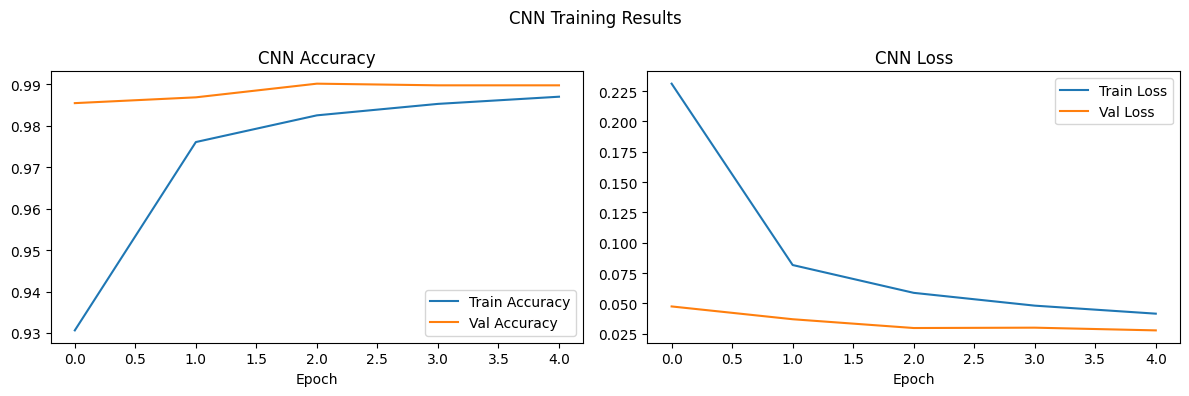

In [4]:
import matplotlib.pyplot as plt

# Plot CNN training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cnn_history.history['accuracy'], label='Train Accuracy')
axes[0].plot(cnn_history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('CNN Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(cnn_history.history['loss'], label='Train Loss')
axes[1].plot(cnn_history.history['val_loss'], label='Val Loss')
axes[1].set_title('CNN Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('CNN Training Results')
plt.tight_layout()
plt.show()

In [5]:
# ==================================
# Transfer Learning with VGG16
# ==================================
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Load VGG16 with ImageNet weights, WITHOUT the top classification layers
# include_top=False: removes VGG16's 1000-class head so we can add our own
# input_shape: VGG16 requires 224x224 RGB images
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze ALL base model layers — we don't want to change ImageNet weights!
# These layers already know how to detect edges, textures, shapes, objects
for layer in base_model.layers:
    layer.trainable = False

print(f"VGG16 has {len(base_model.layers)} layers, all frozen")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
VGG16 has 19 layers, all frozen


In [6]:
# Add our custom classification head on top of VGG16
x = base_model.output

# GlobalAveragePooling2D: reduces 7x7x512 → 512 (much lighter than Flatten)
x = GlobalAveragePooling2D()(x)

# Dense hidden layer: high-level reasoning
x = Dense(1024, activation='relu')(x)

# Output: 10 classes (change this for your specific task)
output = Dense(10, activation='softmax')(x)

# Combine base model + custom head into one model
transfer_model = Model(inputs=base_model.input, outputs=output)

transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # Use when labels are one-hot encoded
    metrics=['accuracy']
)

# Count trainable vs frozen parameters
trainable_params = sum([tf.size(w).numpy() for w in transfer_model.trainable_weights])
frozen_params     = sum([tf.size(w).numpy() for w in transfer_model.non_trainable_weights])
print(f"Trainable parameters: {trainable_params:,}  (our new head)")
print(f"Frozen parameters:    {frozen_params:,}  (VGG16 base — not updated)")

transfer_model.summary()

Trainable parameters: 535,562  (our new head)
Frozen parameters:    14,714,688  (VGG16 base — not updated)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,250,250 (58.18 MB)

 Trainable params: 535,562 (2.04 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

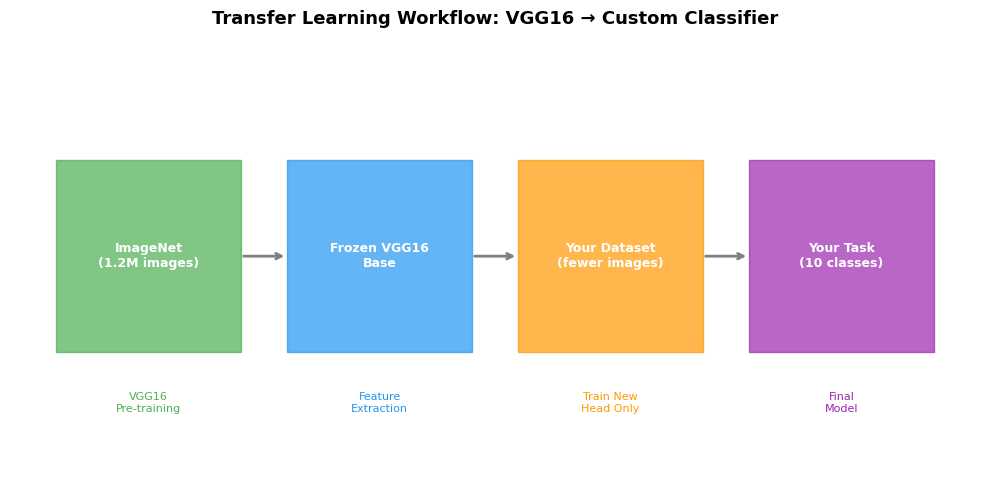

In [7]:
# Visualize the Transfer Learning Concept
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

stages = [
    ("ImageNet\n(1.2M images)", "VGG16\nPre-training", "#4CAF50"),
    ("Frozen VGG16\nBase", "Feature\nExtraction", "#2196F3"),
    ("Your Dataset\n(fewer images)", "Train New\nHead Only", "#FF9800"),
    ("Your Task\n(10 classes)", "Final\nModel", "#9C27B0"),
]

for i, (label, sublabel, color) in enumerate(stages):
    ax.add_patch(plt.Rectangle((i*2.5, 1), 2, 1.5, color=color, alpha=0.7, zorder=2))
    ax.text(i*2.5 + 1, 1.75, label, ha='center', va='center', fontsize=9, fontweight='bold', color='white', zorder=3)
    ax.text(i*2.5 + 1, 0.6, sublabel, ha='center', va='center', fontsize=8, color=color)
    if i < 3:
        ax.annotate('', xy=(i*2.5+2.5, 1.75), xytext=(i*2.5+2, 1.75),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=2))

ax.set_xlim(-0.5, 10)
ax.set_ylim(0, 3.5)
ax.set_title('Transfer Learning Workflow: VGG16 → Custom Classifier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()